
#Particle swarm optimization

In this notebook we will explore the usage of particle swarm optimization methods for the solution of continouos optimization methods.  

> Introduced by Kennedy and Eberhart (1995), is one of the most recent bioinspired metaheuristics

> According to Molina (2020) and Lones et al (2020) it is the most imitated metaheuristic by fake new metaphors    

> We are going to use the [pyswarms](https://pypi.org/project/pyswarms/) package

Just a brief review of the principles of PSO. Here it is the algorithm:

![PSO canonical algorithm](https://docs.google.com/uc?export=download&id=1HgcRLTwcRNQi21h0qoRLyhEsigvM-ATL)


PSO is a framework that represents two main components in the design of metaheuristics (Molina, 2020):

+ "Swarms" of solutions that colaborate in the search process (i.e., stigmergia): "Indirect communication and coordination between solutions or agents used to create new solutions or
exchange information collected during the search process"
+ Diferential vector movement: "A differential vector/movement is used to change the current solution(s) towards new candidate
solution(s)"


#Add the packages that we are going to use for PSO



In [1]:
!pip install pyswarms


   ---------------------------------------- 0/2 [future]
   ---------------------------------------- 0/2 [future]
   ---------------------------------------- 0/2 [future]
   ---------------------------------------- 0/2 [future]
   ---------------------------------------- 0/2 [future]
   ---------------------------------------- 0/2 [future]
   ---------------------------------------- 0/2 [future]
   ---------------------------------------- 0/2 [future]
   ---------------------------------------- 0/2 [future]
   ---------------------------------------- 0/2 [future]
   -------------------- ------------------- 1/2 [pyswarms]
   -------------------- ------------------- 1/2 [pyswarms]
   -------------------- ------------------- 1/2 [pyswarms]
   -------------------- ------------------- 1/2 [pyswarms]
   ---------------------------------------- 2/2 [pyswarms]



#A first simple example

In this example we are going to use a PSO to minimize a bivariate  function:

$f(x_1,x_2)=(x_1-1)^2 + (x_2+1)^2$

Without any aditional constraint



In [2]:
import pyswarms
import numpy as np

# Define the objective function (e.g., minimize x^2 + y^2)
def f(x):
    return (x[:, 0]-1)**2 + (x[:, 1]+1)**2

# Define the number of particles and dimensions
n_particles = 50
n_dimensions = 2

# Initialize the swarm
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
bounds = (np.array([-1, -1]), np.array([1, 1]))

# Create a swarm
swarm = pyswarms.single.GlobalBestPSO(n_particles=n_particles,
                                      dimensions=n_dimensions,
                                      options=options,
                                      bounds=bounds)

# Optimize the function
cost, pos = swarm.optimize(f, iters=200)

print(f"Best position: {pos}")
print(f"Best cost: {cost}")



2025-09-23 08:45:54,011 - pyswarms.single.global_best - INFO - Optimize for 200 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|█████████████████████████████████████████████████████████|200/200, best_cost=0.000625
2025-09-23 08:45:54,279 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0006254746179877316, best pos: [ 0.97970981 -0.98537869]


Best position: [ 0.97970981 -0.98537869]
Best cost: 0.0006254746179877316


#To see how the Swarm advances let see the history of the search

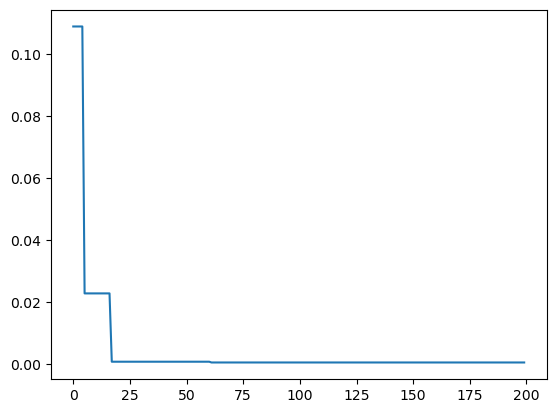

In [3]:
import matplotlib.pyplot as plt

# Obtain the cost history
of_trace=swarm.cost_history
# Obtain the position history
pos_trace=swarm.pos_history
# Obtain the velocity history
speed_trace=swarm.velocity_history

# Plot the OF
plt.plot(of_trace)
plt.show()

#Now the swarm


Using  buil-in functions of pyswarms we are going to visualize the positions of the swarm

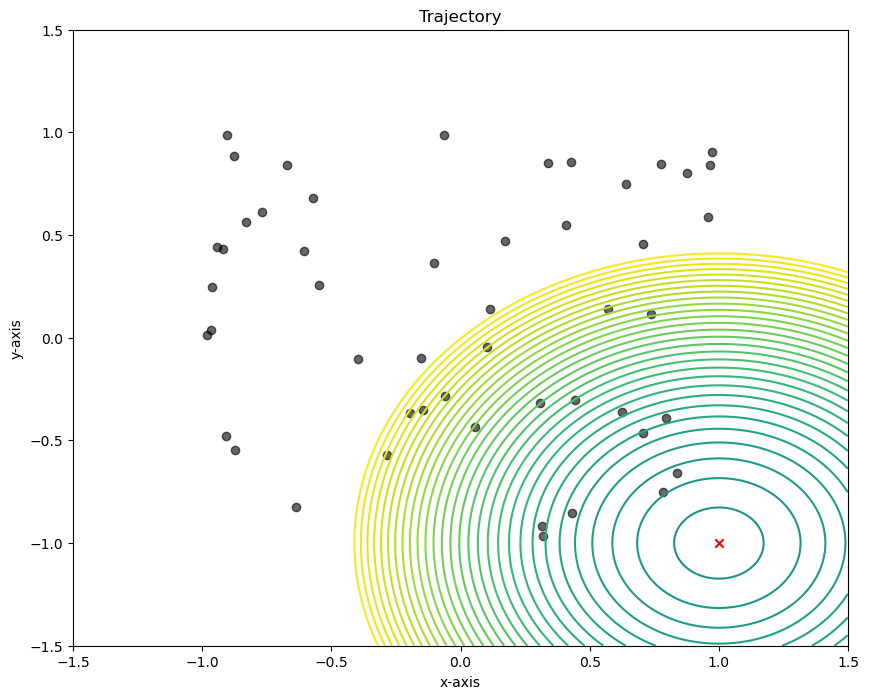

In [4]:
from pyswarms.utils.plotters.formatters import Mesher, Designer
from pyswarms.utils.plotters import plot_cost_history
# Plot the  function's mesh
m = Mesher(func=f,
           limits=[(-1.5,1.5), (-1.5,1.5)])
# Adjust figure limits
d = Designer(limits=[(-1.5,1.5), (-1.5,1.5), (-0.1,1)],
             label=['x-axis', 'y-axis', 'z-axis'])
pyswarms.utils.plotters.plot_contour(pos_history=swarm.pos_history,mesher=m, designer=d, mark=(1,-1))


#Excercise

Now we are going to optimize a more challenging function. The [Ackley function](https://en.wikipedia.org/wiki/Ackley_function#:~:text=In%20mathematical%20optimization%2C%20the%20Ackley,in%20his%201987%20PhD%20dissertation) in 2 dimensions:

![Ackley function Exp](https://docs.google.com/uc?export=download&id=1G8YnxOaHtvX4I4yYrW0QGREop8MzzSig)


![Ackley function](https://docs.google.com/uc?export=download&id=1vNWp2c65Jyu0nH68cbuF8gVUJdD44HJ2)


See [this paper](https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=9213634) for an additional study on the use of PSO for this multimodal function (Cai et al, 2020).



##**Exercise**

+ Create a code to optimize the Ackely function using PSO

In [5]:
from numpy import arange
from numpy import exp
from numpy import sqrt
from numpy import cos
from numpy import e
from numpy import pi
from numpy import meshgrid
import matplotlib.pyplot as plt

def Ackley(x1):
 x=x1[:, 0]
 y=x1[:, 1]
 return -20.0 * exp(-0.2 * sqrt(0.5 * (x**2 + y**2)))-exp(0.5 * (cos(2 *
  pi * x)+cos(2 * pi * y))) + e + 20


#References

+ Cai, W., Yang, L., & Yu, Y. (2020). Solution of Ackley function based on particle swarm optimization algorithm. In 2020 IEEE International Conference on Advances in Electrical Engineering and Computer Applications (AEECA) (pp. 563-566). IEEE.

+ Kennedy, J., & Eberhart, R. (1995). Particle swarm optimization. In Proceedings of ICNN'95-international conference on neural networks (Vol. 4, pp. 1942-1948). IEEE.

+ Lones, M. A. (2020). Mitigating metaphors: A comprehensible guide to recent
nature-inspired algorithms. SN Computer Science, 1(1), 1-12.

+ Molina, D., Poyatos, J., Ser, J. D., García, S., Hussain, A., & Herrera, F. (2020). Comprehensive taxonomies of nature-and bio-inspired optimization: Inspiration versus algorithmic behavior, critical analysis recommendations. Cognitive Computation, 12(5), 897-939.